## Comparing the FS and RS AdEx models using Brian2

#### Ilaria Carannante
mailto: ilaria.carannante@cnrs.fr, ilariac@kth.se
###### NeuroPSI, ICN, Saclay, France

This notebook presents a comparison between two different models: Fast Spiking (FS) and Regular Spiking (RS) *AdEx* models published in [Depannemaecker et al., 2025](https://link.springer.com/article/10.1007/s10827-025-00893-7). 

The classical **AdEx** describes the evolution of the membrane potential $V(t)$ of a single compartment of a neuron membrane. It consists of a system of *two differential equations*:
\begin{align}
    \left\{
    \begin{array}{l}
        C \dfrac{dV}{dt} = -g_{L} (V - E_L) + g_L \Delta_T \exp \left( \dfrac{V - V_\textit{th}}{\Delta_T} \right) - w + I \\
        \tau_w \dfrac{dw}{dt} = a \left( V - E_L \right) - w
    \end{array}
    \right.
\end{align}
When the potential goes beyond ${V}_\textit{th}$, the exponential term generates an upswing of the membrane potential that mimics the exponential activation of $\textrm{\textit{Na}}^+$ channels in a Hodgkin–Huxley-type neuron model, leading to the initiation of an action potential. At a spike detection threshold (e.g. 0 mV), a series of reset conditions is triggered:
\begin{align}
    \left\{
    \begin{array}{l}
        V \rightarrow V_\textit{reset} \\
        w \rightarrow w + b
    \end{array}
    \right.
\end{align}

In this notebook neurons are driven by **current injection**.

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt

In [2]:
import sys
import os

# Adding the project folder to sys.path
cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..'))
sys.path.append(parent_dir)
# We do this so that we can directly import files in the utils folder

In [3]:
from utils.Brian_function_helper import *
from utils.Plots_helper import *

### Defining the current injection protocol

In [4]:
# Defining the delay and the duration of the stimulus (step current injection)
s_delay = 100       # ms
s_duration = 300    # ms
dt = 0.01           # ms

stim_delay = s_delay/dt 
stim_duration = s_duration/dt

# Explicitly defining the time
Time = 500          # ms
time = np.arange(0,Time+dt,dt)

In [5]:
# Explicitly defining the intensity of the current
amp = 0.35           #nA

In [6]:
data_folder = '../neuron_models/AdEx'
idx = 0 # in this case only one model per cell type is provided

In [7]:
# Defining the current injection structure
stim_t_start = int(stim_delay * dt)
stim_t_end = int(stim_duration * dt + stim_t_start)
stim_unit = 1. * b2.ms
stim_amplitude = amp * b2.nA
stim_time = Time * b2.ms

# Setting up the step current injection protocol
tmp_size = 2 + stim_t_end  
tmp = np.zeros((tmp_size, 1)) * b2.amp
tmp[stim_t_start: stim_t_end + 1, 0] = stim_amplitude
curr_array = b2.TimedArray(tmp, dt=1. * stim_unit).values.flatten()  # to solve the issue with dimention of the current vector
current_timed_array = b2.TimedArray(curr_array * b2.amp, dt=stim_unit)

### Setting up the neuron models

In [8]:
neuron_model = 'FS'

G_inh = setting_simulation_Brian(idx = idx,
                                 neuron_model = neuron_model,
                                 json_file_name = os.path.join(data_folder, neuron_model + '.json'),
                                 curr_inj = current_timed_array)

neuron_model = 'RS'
G_exc = setting_simulation_Brian(idx = idx,
                                 neuron_model = neuron_model,
                                 json_file_name = os.path.join(data_folder, neuron_model + '.json'),
                                 curr_inj = current_timed_array)


### Defining the Monitors (variables to record)

In [9]:
mon_FS = b2.StateMonitor(G_inh, ['v', 'Is'], record=True)
#mon_FS_rate = b2.PopulationRateMonitor(G_inh) # not ideal, only 1 neuron in the population
mon_spike_FS = b2.SpikeMonitor(G_inh)

mon_RS = b2.StateMonitor(G_exc, ['v', 'Is'], record=True)
mon_spike_RS = b2.SpikeMonitor(G_exc)


In [10]:
# to explore what's in the Monitor, use:
# print(dir(mon_FS))
# or for more details
# help(mon_FS)

### Running the simulation of the three neuron models

In [11]:
%%time
b2.run(stim_time, namespace={'current': current_timed_array})

CPU times: user 742 ms, sys: 46.7 ms, total: 789 ms
Wall time: 2.86 s


### Plotting the results

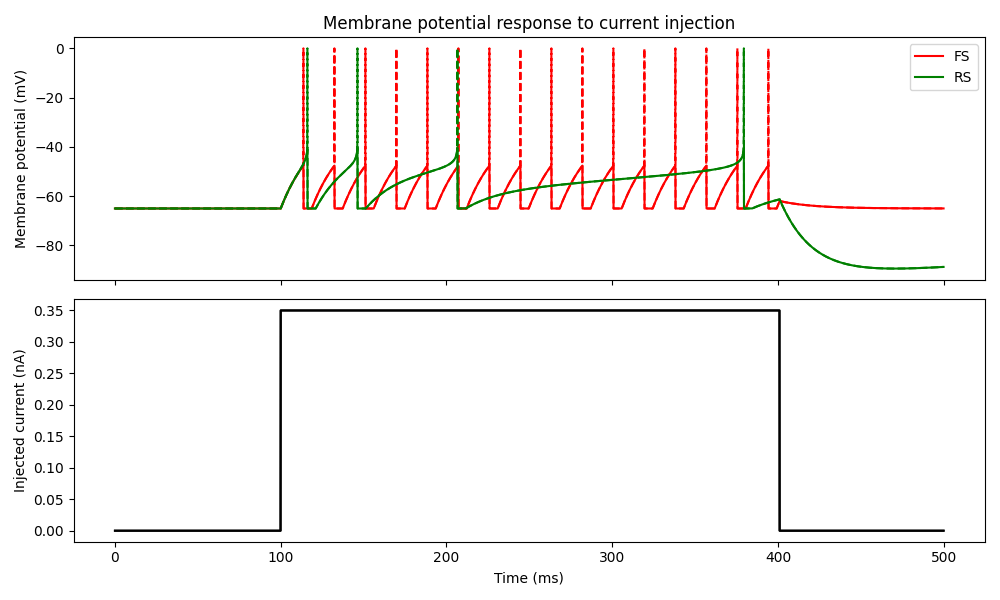

In [12]:
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

v_RS_plot = get_pretty_voltage(mon_RS.v[0], -50)
v_FS_plot = get_pretty_voltage(mon_FS.v[0], -50)

ax[0].plot(mon_FS.t / b2.ms, mon_FS.v[0] / b2.mV, color='red', label = 'FS')
ax[0].plot(mon_RS.t / b2.ms, v_FS_plot / b2.mV, '--' , color='red')

ax[0].plot(mon_RS.t / b2.ms, mon_RS.v[0] / b2.mV, color='green', label = 'RS')
ax[0].plot(mon_RS.t / b2.ms, v_RS_plot / b2.mV, '--' , color='green')

ax[0].set_ylabel('Membrane potential (mV)')
ax[0].set_title('Membrane potential response to current injection')

ax[1].plot(mon_FS.t / b2.ms, mon_FS.Is[0] / b2.nA, color='black')
ax[1].plot(mon_RS.t / b2.ms, mon_RS.Is[0] / b2.nA, color='black') # sanity check

ax[1].set_ylabel('Injected current (nA)')
ax[1].set_xlabel('Time (ms)')

plt.tight_layout()
ax[0].legend()


In [13]:
stim_duration = s_duration * b2.ms

n_spikes_FS = mon_spike_FS.count[0]
avg_rate_FS = n_spikes_FS / stim_duration
print(f"Average FS firing rate: {avg_rate_FS / b2.Hz:.2f} Hz")

n_spikes_RS = mon_spike_RS.count[0]
avg_rate_RS = n_spikes_RS / stim_duration
print(f"Average RS firing rate: {avg_rate_RS / b2.Hz:.2f} Hz")

Average FS firing rate: 53.33 Hz
Average RS firing rate: 13.33 Hz
